In [1]:
from qubic.lib.MapMaking.Qmap_plotter import plot_cross_spectrum
import pickle

hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).


In [2]:
pkl = pickle.load(open("test_spectra/Spectrum/spectrum_test_None.pkl", "rb"))
pkl.keys()

dict_keys(['nus', 'ell', 'Dls', 'Nls', 'parameters', 'delta_ell', 'fsky'])

In [3]:
nus = pkl["nus"]
ell = pkl["ell"]
Dls = pkl["Dls"]
Nls = pkl["Nls"]

Dls_noiseless = Dls - Nls

print("nus", nus.shape, nus)
print("ell", ell.shape, ell)
print("Dls", Dls.shape)
print("Nls", Nls.shape)

nus (9,) [149. 219.  30.  44.  70. 100. 143. 217. 353.]
ell (8,) [ 16.5  46.5  76.5 106.5 136.5 166.5 196.5 226.5]
Dls (9, 9, 8)
Nls (9, 9, 8)


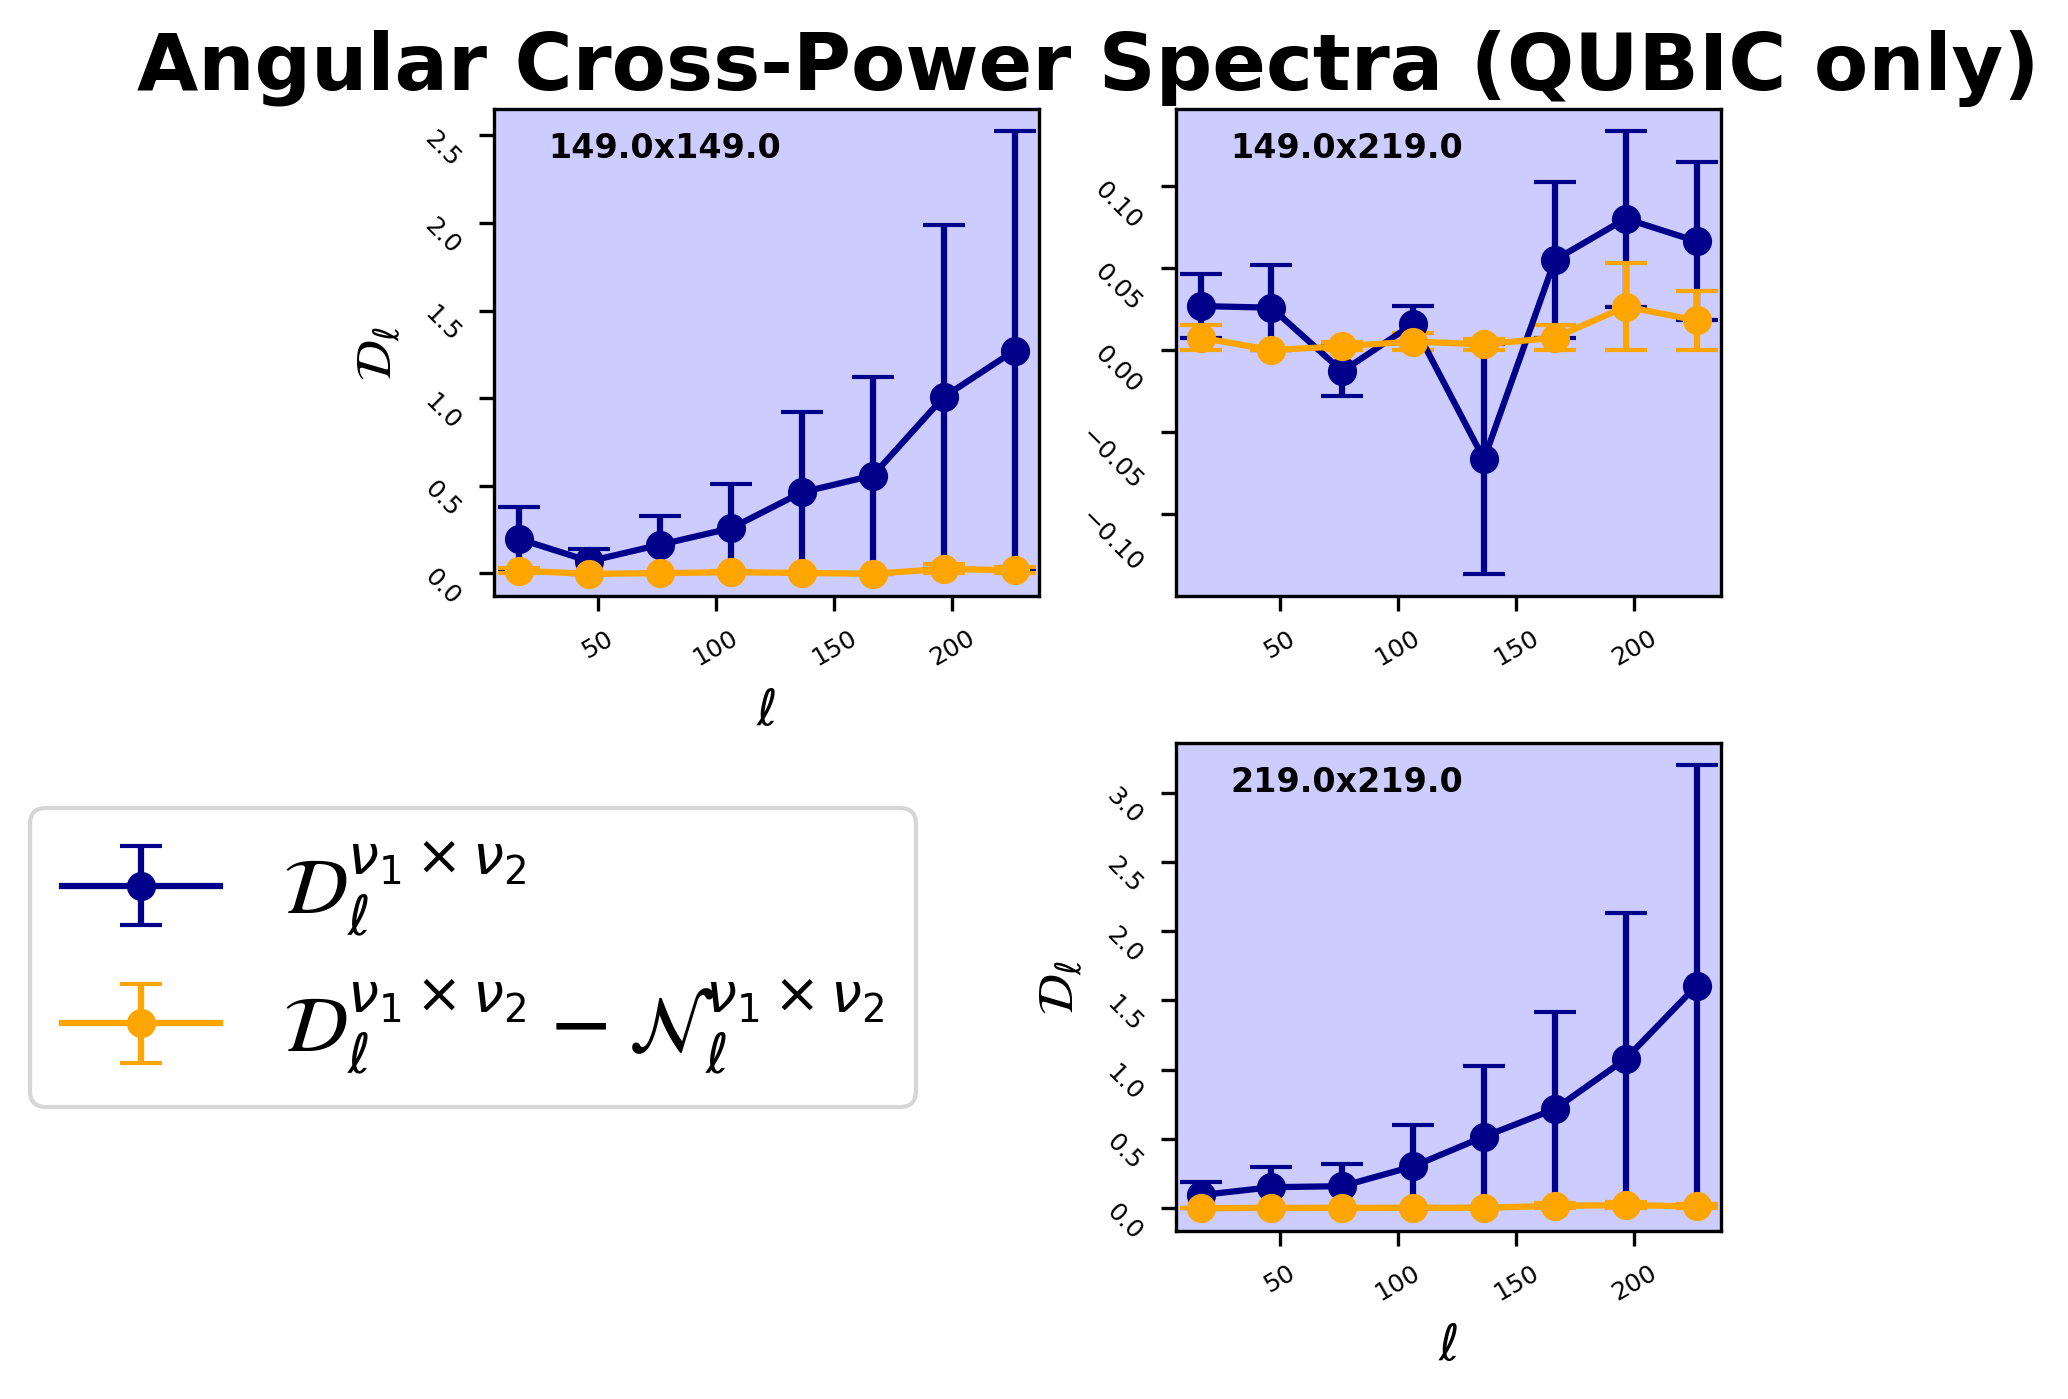

In [4]:
### QUBIC only
N = nus.size - 7
plot_cross_spectrum(
    nus=nus[:N],
    ell=ell,
    Dl=Dls[:N, :N],
    Dl_err=Nls[:N, :N],
    ymodel=None,
    mode="Dl",
    nrec=N,
    # figsize=(12, 10),
    title=" (QUBIC only)",
)

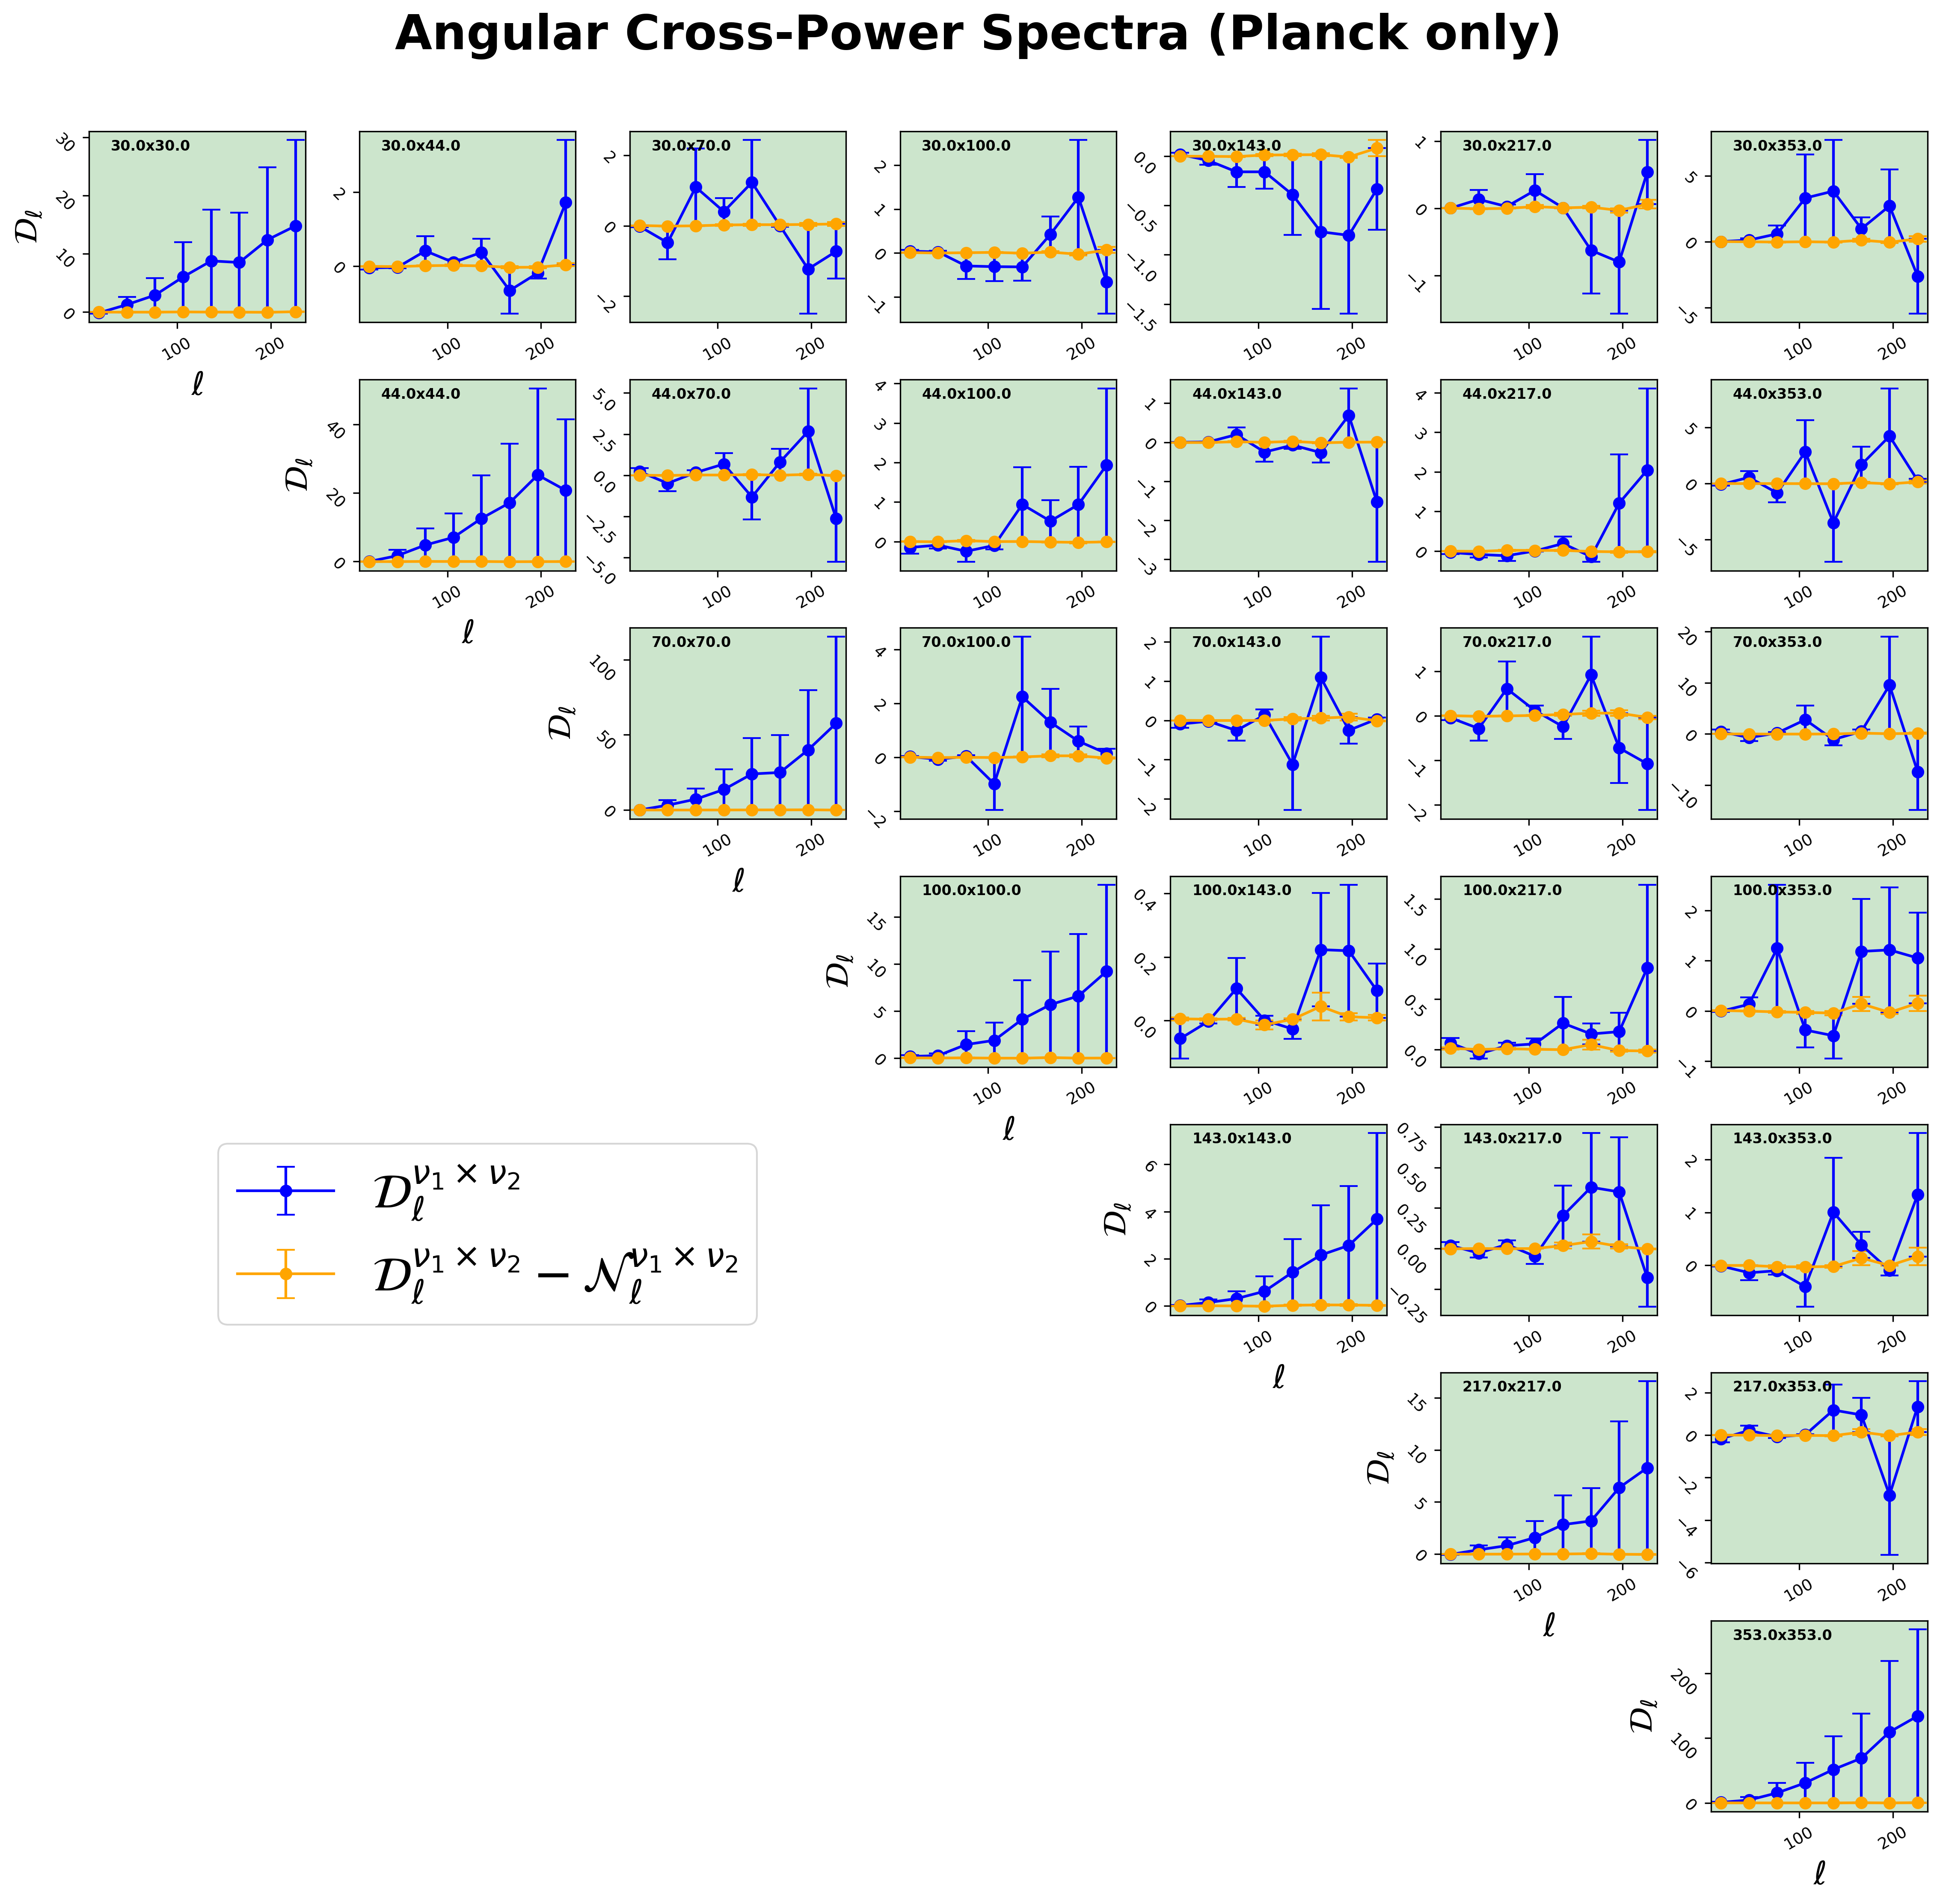

In [5]:
### Planck only
N = nus.size - 7
plot_cross_spectrum(
    nus=nus[N:],
    ell=ell,
    Dl=Dls[N:, N:],
    Dl_err=Nls[N:, N:],
    ymodel=None,
    mode="Dl",
    nrec=0,
    # figsize=(25, 25),
    title =" (Planck only)"
)

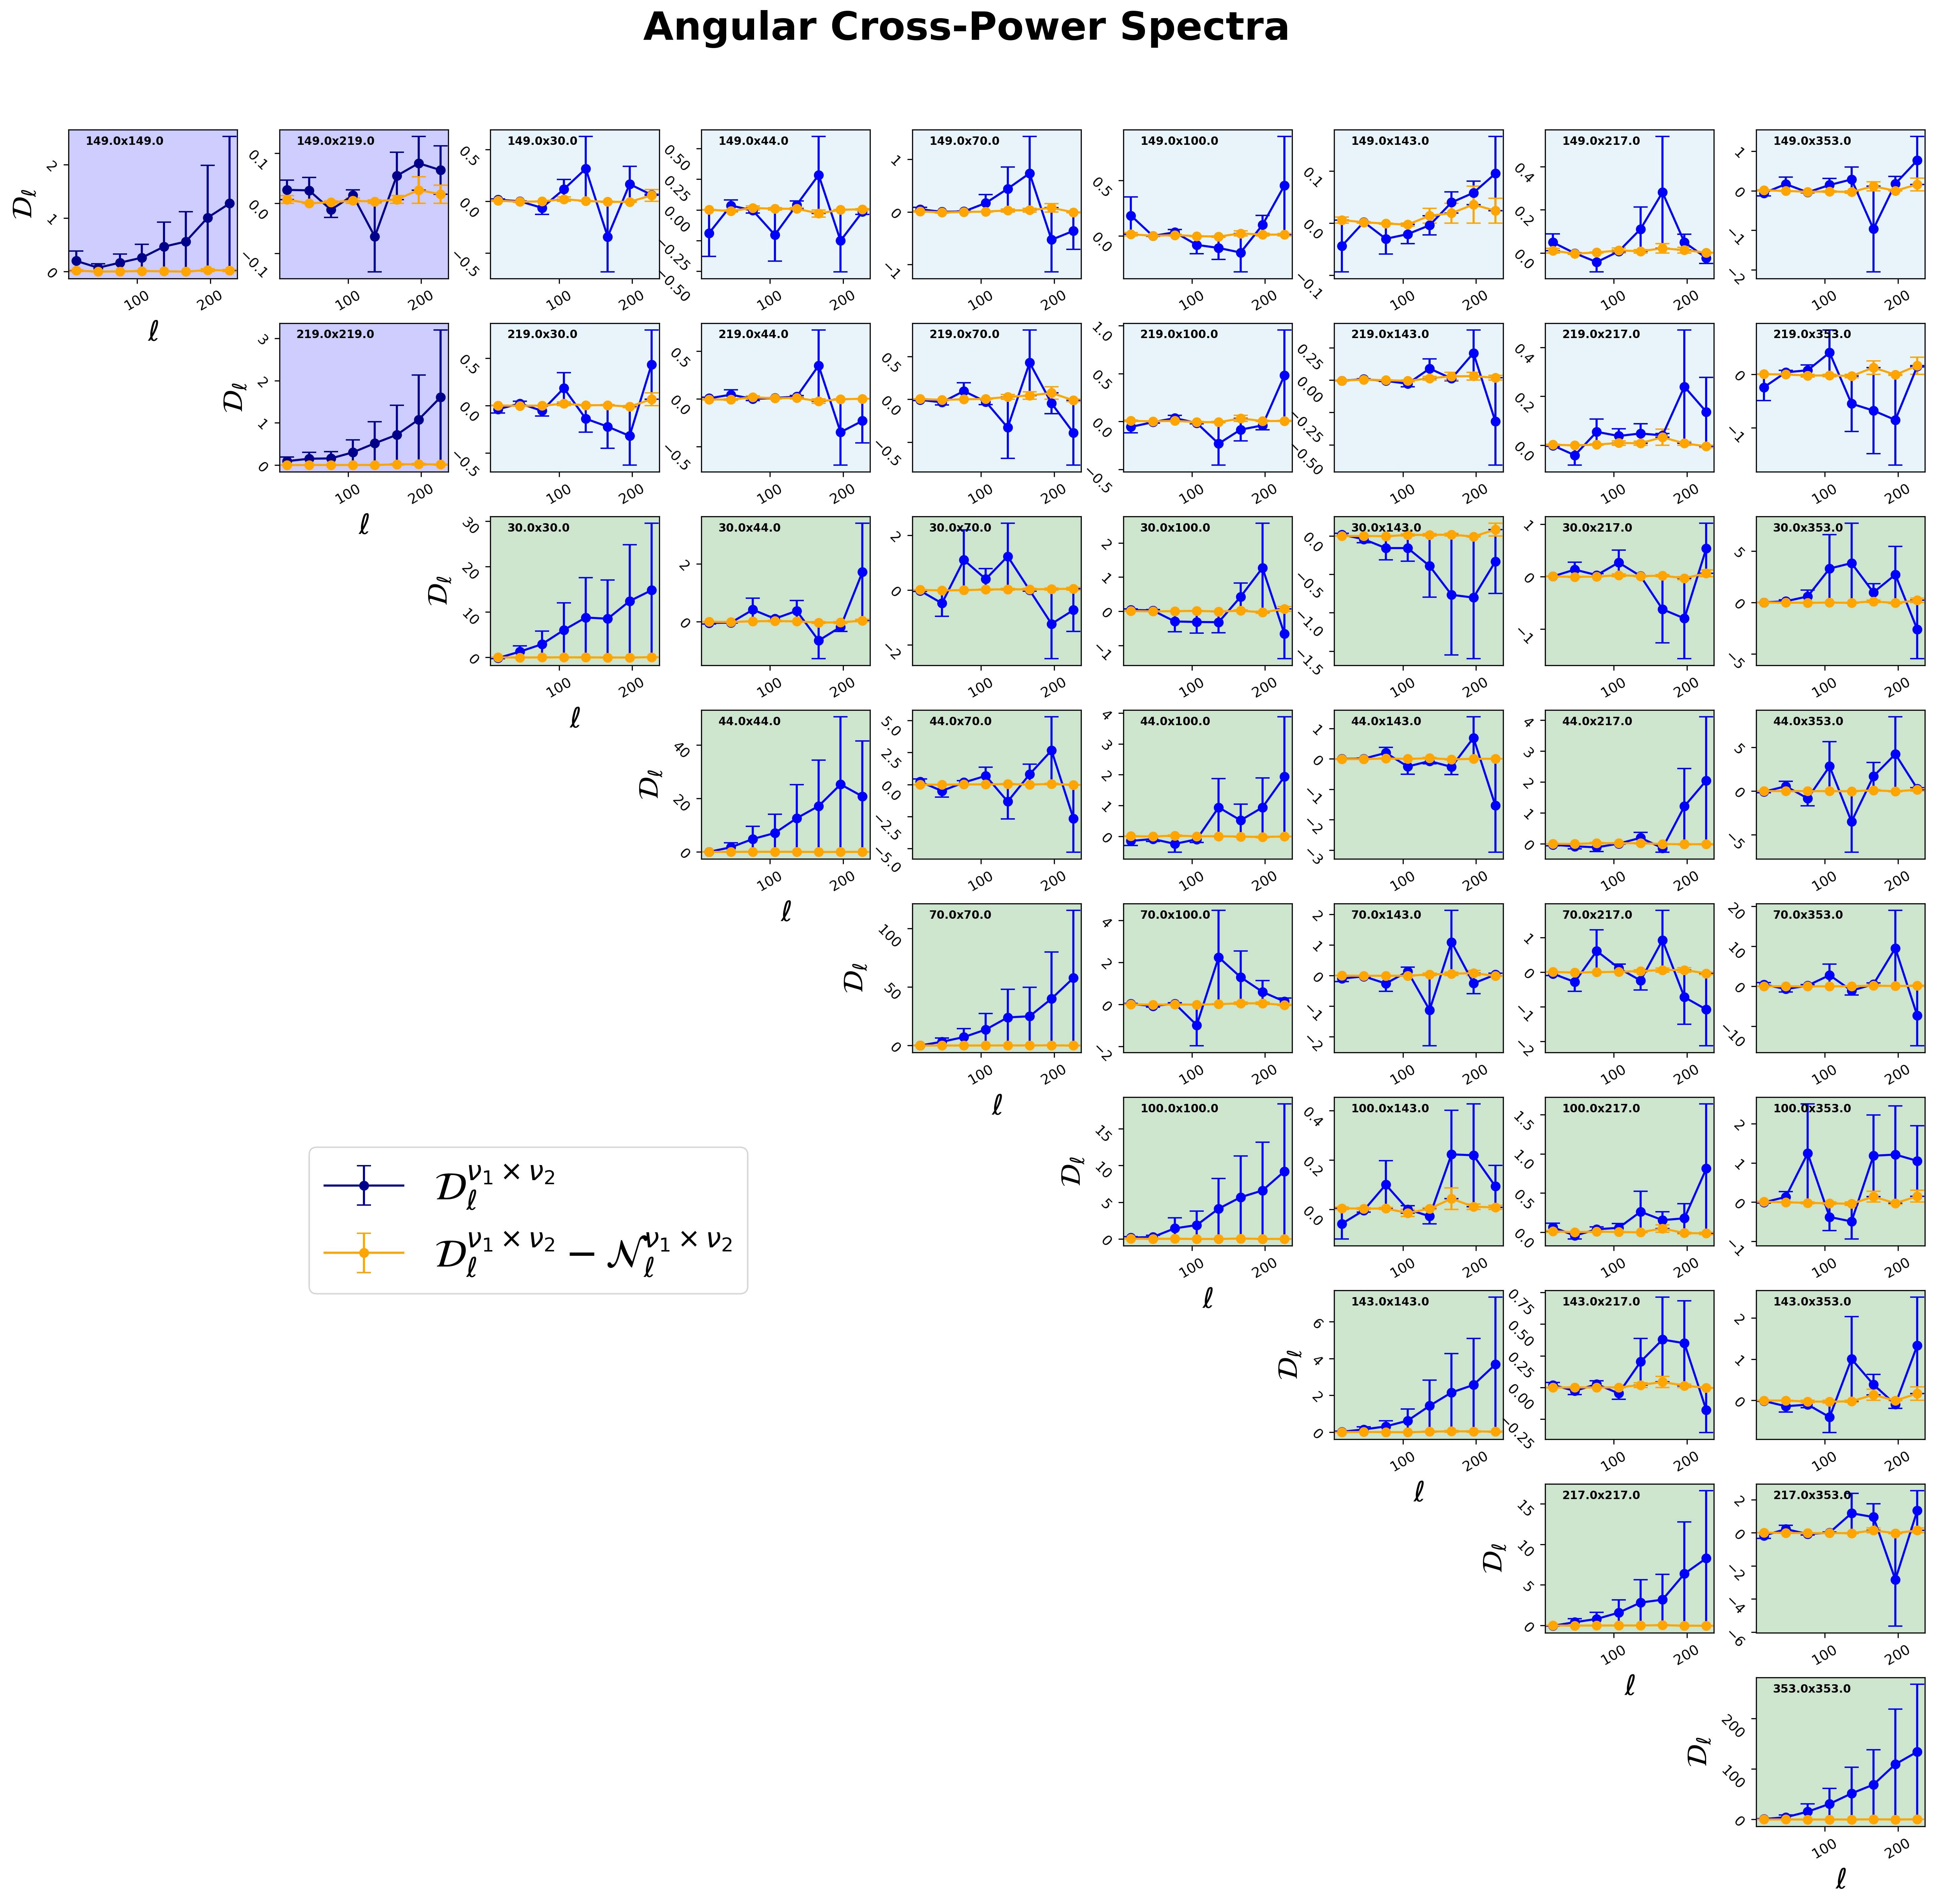

In [6]:
### QUBIC + Planck 
plot_cross_spectrum(
    nus=nus,
    ell=ell,
    Dl=Dls,
    Dl_err=Nls,
    ymodel=None,
    mode="Dl",
    nrec=N,
    # figsize=(30, 30),
)